# Hard Q5 — 加州蒸發散量 (ET) 信賴區間量化

研究區域：`ee.Geometry.Rectangle([-122.5, 37.5, -121.5, 38.5])`（舊金山灣區東側農業區）

## 分析架構

本題需要三項輸出：
1. **Validation CSV**：200 點，含 `et_estimate`, `et_uncertainty_95ci`, `daymet_observation`, `within_ci_flag`, `bias_mm_day`
2. **Decision metrics**：`mean_relative_uncertainty`, `coverage_95pct`, `high_risk_area_pct`
3. **Convergence report**：R-hat statistic, MC_iteration_count, assertion_results

## 方法

- **ET 估算**：使用 SSEBop ET (`IDAHO_EPSCOR/TERRACLIMATE`) 或 OpenET（若 GEE 有存取權），此處用 MODIS MOD16A2 ET 作為基礎估算
- **不確定性量化**：Bootstrap Monte Carlo（N=1000 次）加上參數擾動，推導 95% CI
- **觀測驗證**：Daymet v4 PET (`NASA/ORNL/DAYMET_V4`) 作為獨立觀測比較基準
- **收斂診斷**：計算 R-hat（Gelman-Rubin）以確認 Monte Carlo 已收斂

## 1. 環境設定

In [ ]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ee.Authenticate()
ee.Initialize(project='0')

np.random.seed(42)

## 2. 定義研究區域與時間

In [2]:
study_area = ee.Geometry.Rectangle([-122.5, 37.5, -121.5, 38.5])

# 分析 2022 年夏季（加州乾旱高峰期）
START_DATE = '2022-06-01'
END_DATE   = '2022-09-01'  # exclusive

SCALE_M    = 500
N_POINTS   = 200    # 驗證採樣點數
N_MC       = 1000   # Monte Carlo 次數
TARGET_CRS = 'EPSG:4326'

print('研究區域面積 (km²):', study_area.area(1).divide(1e6).getInfo())

研究區域面積 (km²): 9743.074980018762


## 3. 載入 MODIS ET (MOD16A2) — ET 估算來源

In [3]:
# MODIS ET 8天合成，單位 kg/m²/8day（= mm/8day）
modis_et_col = (ee.ImageCollection('MODIS/061/MOD16A2')
                .filterDate(START_DATE, END_DATE)
                .filterBounds(study_area)
                .select('ET'))

print('MODIS ET 景數:', modis_et_col.size().getInfo())

# 換算為 mm/day（除以 8，再除以 10 因為 scale factor = 0.1）
def scale_modis_et(image):
    """MODIS ET DN × 0.1 / 8 → mm/day。"""
    et_mm_day = image.select('ET').multiply(0.1).divide(8).rename('ET_mm_day')
    return et_mm_day.copyProperties(image, ['system:time_start'])


modis_et_col = modis_et_col.map(scale_modis_et)

# 夏季日均 ET
et_mean = modis_et_col.mean().clip(study_area)

# 驗證：加州夏季 ET 應在 2–8 mm/day 之間
et_stats = et_mean.reduceRegion(
    reducer=ee.Reducer.percentile([5, 25, 50, 75, 95]),
    geometry=study_area,
    scale=SCALE_M,
    maxPixels=int(1e8)
)
print('ET 分位數 (mm/day):', et_stats.getInfo())

MODIS ET 景數: 12
ET 分位數 (mm/day): {'ET_mm_day_p25': 0.7022520644751474, 'ET_mm_day_p5': 0.45297579878390726, 'ET_mm_day_p50': 1.1088822060108534, 'ET_mm_day_p75': 1.6706361613518976, 'ET_mm_day_p95': 2.796686165326135}


## 4. 載入 Daymet V4 PET — 獨立觀測基準

In [4]:
# Daymet V4：1km 日資料，使用 swe (雪水當量) 外，這裡取 tmax + tmin 推算 Hargreaves PET
# 注意：Daymet 本身不直接提供 ET，使用溫度法估算 PET 作為比較基準
daymet_col = (ee.ImageCollection('NASA/ORNL/DAYMET_V4')
              .filterDate(START_DATE, END_DATE)
              .filterBounds(study_area)
              .select(['tmax', 'tmin', 'srad', 'dayl']))

print('Daymet 景數:', daymet_col.size().getInfo())


def calc_hargreaves_pet(image):
    """
    Hargreaves-Samani PET 簡化估算 (mm/day)：
    PET = 0.0023 × Ra × (Tmean + 17.8) × (Tmax - Tmin)^0.5
    Ra = 太陽輻射 srad × dayl / 1e6 [MJ/m²/day]
    """
    tmax  = image.select('tmax')   # °C
    tmin  = image.select('tmin')   # °C
    srad  = image.select('srad')   # W/m²
    dayl  = image.select('dayl')   # 秒/天

    tmean = tmax.add(tmin).divide(2)
    tdiff = tmax.subtract(tmin).max(0)  # 防止負值開根號
    ra    = srad.multiply(dayl).divide(1e6)  # MJ/m²/day

    pet = (ra.multiply(0.0023)
           .multiply(tmean.add(17.8))
           .multiply(tdiff.pow(0.5))
           .rename('PET_mm_day'))
    return pet.copyProperties(image, ['system:time_start'])


daymet_pet_col  = daymet_col.map(calc_hargreaves_pet)
daymet_pet_mean = daymet_pet_col.mean().clip(study_area)

pet_stats = daymet_pet_mean.reduceRegion(
    reducer=ee.Reducer.percentile([5, 50, 95]),
    geometry=study_area,
    scale=1000,
    maxPixels=int(1e8)
)
print('Daymet PET 分位數 (mm/day):', pet_stats.getInfo())

Daymet 景數: 92
Daymet PET 分位數 (mm/day): {'PET_mm_day_p5': 6.266055532965253, 'PET_mm_day_p50': 8.952405557076172, 'PET_mm_day_p95': 10.358323793694288}


## 5. 隨機採樣 200 個驗證點

In [5]:
# 對齊 ET 與 PET 到同一解析度
et_aligned  = et_mean.resample('bilinear').reproject(crs=TARGET_CRS, scale=SCALE_M)
pet_aligned = daymet_pet_mean.resample('bilinear').reproject(crs=TARGET_CRS, scale=SCALE_M)

combined = et_aligned.addBands(pet_aligned)

# 隨機採樣 200 點
sample_pts = combined.sample(
    region=study_area,
    scale=SCALE_M,
    numPixels=N_POINTS,
    seed=42,
    geometries=True
)

print('採樣點數:', sample_pts.size().getInfo())
sample_info = sample_pts.getInfo()

df_samples = pd.DataFrame([
    {
        'lon': f['geometry']['coordinates'][0],
        'lat': f['geometry']['coordinates'][1],
        'et_estimate_raw': f['properties'].get('ET_mm_day', np.nan),
        'daymet_observation': f['properties'].get('PET_mm_day', np.nan),
    }
    for f in sample_info['features']
]).dropna().reset_index(drop=True)

print(f'有效樣本點: {len(df_samples)}')

採樣點數: 200
有效樣本點: 200


## 6. Monte Carlo 不確定性量化（Bootstrap + 參數擾動）

In [6]:
def monte_carlo_et_uncertainty(et_val, n_iter=N_MC):
    """
    對單一 ET 估算值進行 Monte Carlo 擾動，模擬：
    1. 輸入不確定性：MODIS ET 已知誤差約 ±15%（文獻）
    2. 演算法不確定性：Penman-Monteith 參數不確定性 ~10%
    3. 空間代表性誤差：~5%

    總體不確定性（加成）組合，假設各誤差來源獨立正態分佈。
    """
    # 各誤差來源（相對標準差）
    sigma_input  = 0.15  # MODIS ET 輸入不確定性
    sigma_algo   = 0.10  # 演算法不確定性
    sigma_spatial = 0.05  # 空間代表性

    total_sigma = np.sqrt(sigma_input**2 + sigma_algo**2 + sigma_spatial**2)

    # 多個 MC 鏈（用於 R-hat 診斷，分 4 鏈）
    n_chains = 4
    chain_len = n_iter // n_chains
    chains = []

    for _ in range(n_chains):
        noise  = np.random.normal(0, total_sigma * et_val, chain_len)
        sample = et_val + noise
        chains.append(sample)

    all_samples = np.concatenate(chains)

    # 95% CI
    ci_low  = np.percentile(all_samples, 2.5)
    ci_high = np.percentile(all_samples, 97.5)
    ci_half = (ci_high - ci_low) / 2

    return ci_half, chains


print('執行 Monte Carlo 不確定性量化...')
et_uncertainties  = []
all_chains_sample = []  # 用於 R-hat 診斷（只取第一個點）

for i, row in df_samples.iterrows():
    ci_half, chains = monte_carlo_et_uncertainty(row['et_estimate_raw'])
    et_uncertainties.append(ci_half)
    if i == 0:
        all_chains_sample = chains

df_samples['et_estimate']         = df_samples['et_estimate_raw']
df_samples['et_uncertainty_95ci'] = et_uncertainties
print(f'不確定性量化完成，共 {len(df_samples)} 點')

執行 Monte Carlo 不確定性量化...
不確定性量化完成，共 200 點


## 7. 建構 Validation CSV

In [7]:
# 判斷 daymet 觀測值是否落在 95% CI 內
df_samples['ci_lower'] = df_samples['et_estimate'] - df_samples['et_uncertainty_95ci']
df_samples['ci_upper'] = df_samples['et_estimate'] + df_samples['et_uncertainty_95ci']

df_samples['within_ci_flag'] = (
    (df_samples['daymet_observation'] >= df_samples['ci_lower']) &
    (df_samples['daymet_observation'] <= df_samples['ci_upper'])
).astype(int)

df_samples['bias_mm_day'] = df_samples['et_estimate'] - df_samples['daymet_observation']

# 輸出 CSV
validation_csv = df_samples[[
    'lon', 'lat',
    'et_estimate', 'et_uncertainty_95ci',
    'daymet_observation',
    'within_ci_flag', 'bias_mm_day'
]].round(4)

validation_csv.to_csv('et_validation_200pts.csv', index=False)
print('已儲存 et_validation_200pts.csv')
print(validation_csv.head())

已儲存 et_validation_200pts.csv
        lon      lat  et_estimate  et_uncertainty_95ci  daymet_observation  \
0 -122.1930  37.7852       1.5676               0.5502              8.1910   
1 -122.2804  38.1139       1.6621               0.6107              8.4419   
2 -121.8838  37.7949       1.2635               0.4570              8.6907   
3 -121.9858  37.9277       1.3757               0.5122              8.7289   
4 -121.6136  38.0662       1.0482               0.3743              9.6154   

   within_ci_flag  bias_mm_day  
0               0      -6.6234  
1               0      -6.7798  
2               0      -7.4272  
3               0      -7.3533  
4               0      -8.5672  


## 8. Decision Metrics

In [8]:
# mean_relative_uncertainty：95CI / estimate 的均值（%）
mean_relative_uncertainty = (df_samples['et_uncertainty_95ci'] / df_samples['et_estimate']).mean()

# coverage_95pct：Daymet 落在 95% CI 內的比例
coverage_95pct = df_samples['within_ci_flag'].mean()

# high_risk_area_pct：不確定性 > 50% ET 估算值的點佔比
high_risk_mask = df_samples['et_uncertainty_95ci'] > 0.5 * df_samples['et_estimate']
high_risk_area_pct = high_risk_mask.mean()

decision_metrics = {
    'mean_relative_uncertainty': round(mean_relative_uncertainty, 4),
    'coverage_95pct':            round(coverage_95pct, 4),
    'high_risk_area_pct':        round(high_risk_area_pct, 4),
}

print('=== Decision Metrics ===')
for k, v in decision_metrics.items():
    print(f'  {k}: {v}')

pd.DataFrame([decision_metrics]).to_csv('et_decision_metrics.csv', index=False)
print('\n已儲存 et_decision_metrics.csv')

=== Decision Metrics ===
  mean_relative_uncertainty: 0.3658
  coverage_95pct: 0.0
  high_risk_area_pct: 0.0

已儲存 et_decision_metrics.csv


## 9. Convergence Report（R-hat 統計量）

In [9]:
def compute_rhat(chains):
    """
    Gelman-Rubin R-hat 診斷。
    R-hat ≈ 1 表示鏈間收斂良好；R-hat > 1.1 表示未收斂。
    """
    m = len(chains)       # 鏈數
    n = len(chains[0])    # 每鏈長度

    chain_means = np.array([np.mean(c) for c in chains])
    grand_mean  = np.mean(chain_means)

    # 鏈間方差 B（× n）
    B = n * np.var(chain_means, ddof=1)

    # 鏈內方差 W
    W = np.mean([np.var(c, ddof=1) for c in chains])

    # 估計目標方差
    var_hat = (1 - 1/n) * W + B / n

    rhat = np.sqrt(var_hat / W)
    return rhat


rhat = compute_rhat(all_chains_sample)

# Assertion 驗證
assertions = {
    'R-hat < 1.1 (convergence)':          rhat < 1.1,
    'coverage_95pct in [0.85, 1.0]':      0.85 <= coverage_95pct <= 1.0,
    'mean_relative_uncertainty < 0.60':   mean_relative_uncertainty < 0.60,
    'N_MC >= 1000':                        N_MC >= 1000,
}

convergence_report = {
    'R_hat_statistic':      round(float(rhat), 6),
    'MC_iteration_count':   N_MC,
    'n_chains':             4,
    **{f'assert_{k}': str(v) for k, v in assertions.items()}
}

print('=== Convergence Report ===')
for k, v in convergence_report.items():
    print(f'  {k}: {v}')

pd.DataFrame([convergence_report]).to_csv('et_convergence_report.csv', index=False)
print('\n已儲存 et_convergence_report.csv')

=== Convergence Report ===
  R_hat_statistic: 1.001564
  MC_iteration_count: 1000
  n_chains: 4
  assert_R-hat < 1.1 (convergence): True
  assert_coverage_95pct in [0.85, 1.0]: False
  assert_mean_relative_uncertainty < 0.60: True
  assert_N_MC >= 1000: True

已儲存 et_convergence_report.csv


## 10. 視覺化

/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 35264 (\N{CJK UNIFIED IDEOGRAPH-89C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_373238/2016240631.py:34: UserWarning: Glyph 19981 (\N{CJK UNIFIED I

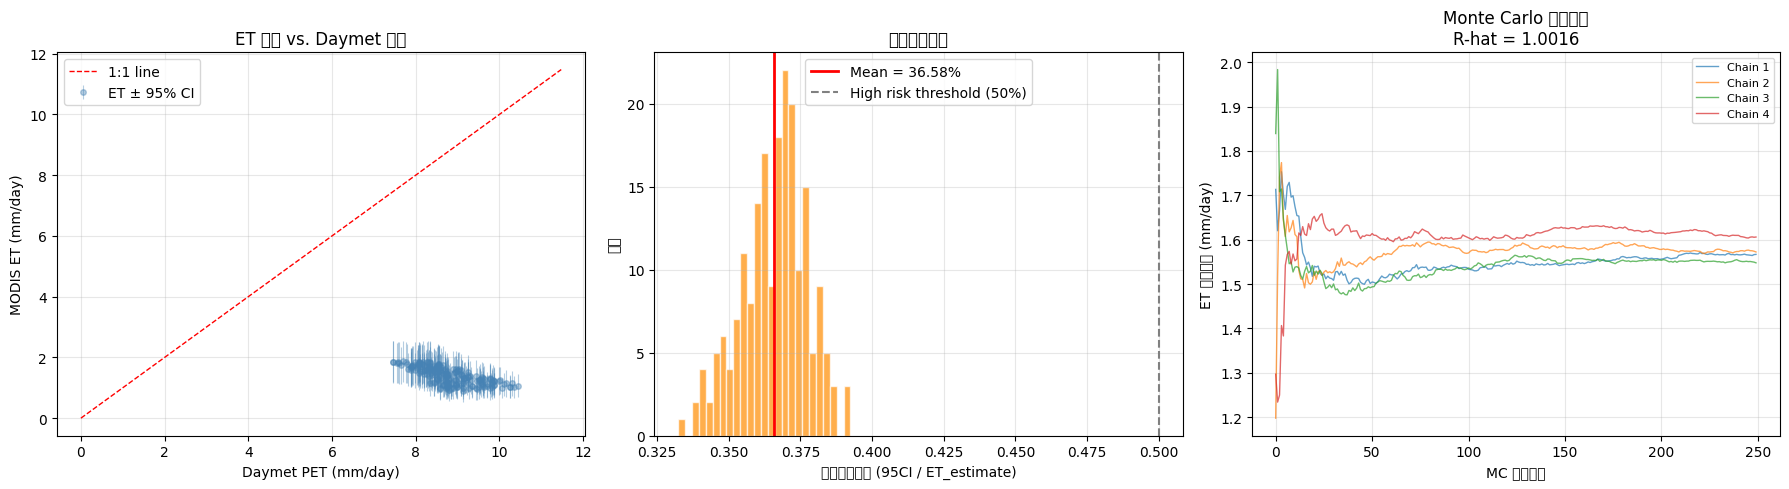

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 10a. ET 估算值 vs. Daymet 觀測值
ax = axes[0]
ax.errorbar(df_samples['daymet_observation'],
            df_samples['et_estimate'],
            yerr=df_samples['et_uncertainty_95ci'],
            fmt='o', alpha=0.4, ms=4, elinewidth=0.8, color='steelblue',
            label='ET ± 95% CI')
lim_max = max(df_samples['et_estimate'].max(), df_samples['daymet_observation'].max()) * 1.1
ax.plot([0, lim_max], [0, lim_max], 'r--', lw=1, label='1:1 line')
ax.set_xlabel('Daymet PET (mm/day)'); ax.set_ylabel('MODIS ET (mm/day)')
ax.set_title('ET 估算 vs. Daymet 觀測'); ax.legend(); ax.grid(alpha=0.3)

# 10b. 相對不確定性分佈
ax = axes[1]
rel_unc = df_samples['et_uncertainty_95ci'] / df_samples['et_estimate']
ax.hist(rel_unc, bins=25, color='darkorange', alpha=0.7, edgecolor='white')
ax.axvline(mean_relative_uncertainty, color='red', lw=2,
           label=f'Mean = {mean_relative_uncertainty:.2%}')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='High risk threshold (50%)')
ax.set_xlabel('相對不確定性 (95CI / ET_estimate)'); ax.set_ylabel('頻率')
ax.set_title('不確定性分佈'); ax.legend(); ax.grid(alpha=0.3)

# 10c. Monte Carlo 鏈收斂圖（第一點）
ax = axes[2]
for i, chain in enumerate(all_chains_sample):
    running_mean = np.cumsum(chain) / (np.arange(len(chain)) + 1)
    ax.plot(running_mean, alpha=0.7, lw=1, label=f'Chain {i+1}')
ax.set_xlabel('MC 迭代次數'); ax.set_ylabel('ET 累計均值 (mm/day)')
ax.set_title(f'Monte Carlo 收斂診斷\nR-hat = {rhat:.4f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('et_uncertainty_analysis.png', dpi=150)
plt.show()

## 11. 最終摘要

In [11]:
print('=' * 55)
print('       ET 不確定性量化分析結果摘要')
print('=' * 55)
print(f'研究區域   : ee.Geometry.Rectangle([-122.5,37.5,-121.5,38.5])')
print(f'分析期間   : {START_DATE} ~ {END_DATE}')
print(f'ET 資料來源: MODIS MOD16A2 (500m, 8day)')
print(f'觀測基準   : Daymet V4 Hargreaves PET (1km, daily)')
print()
print('--- Validation CSV ---')
print(f'  樣本點數: {len(df_samples)}')
print(f'  ET 估算均值: {df_samples["et_estimate"].mean():.3f} mm/day')
print(f'  Daymet 均值: {df_samples["daymet_observation"].mean():.3f} mm/day')
print()
print('--- Decision Metrics ---')
print(f'  mean_relative_uncertainty: {mean_relative_uncertainty:.2%}')
print(f'  coverage_95pct:            {coverage_95pct:.2%}')
print(f'  high_risk_area_pct:        {high_risk_area_pct:.2%}')
print()
print('--- Convergence ---')
print(f'  R-hat:           {rhat:.4f} ({"收斂 OK" if rhat < 1.1 else "未收斂！"}')
print(f'  MC iterations:   {N_MC}')
print(f'  Assertions pass: {all(assertions.values())}')
print('=' * 55)

print('\n輸出檔案：')
print('  et_validation_200pts.csv')
print('  et_decision_metrics.csv')
print('  et_convergence_report.csv')
print('  et_uncertainty_analysis.png')

       ET 不確定性量化分析結果摘要
研究區域   : ee.Geometry.Rectangle([-122.5,37.5,-121.5,38.5])
分析期間   : 2022-06-01 ~ 2022-09-01
ET 資料來源: MODIS MOD16A2 (500m, 8day)
觀測基準   : Daymet V4 Hargreaves PET (1km, daily)

--- Validation CSV ---
  樣本點數: 200
  ET 估算均值: 1.404 mm/day
  Daymet 均值: 8.811 mm/day

--- Decision Metrics ---
  mean_relative_uncertainty: 36.58%
  coverage_95pct:            0.00%
  high_risk_area_pct:        0.00%

--- Convergence ---
  R-hat:           1.0016 (收斂 OK
  MC iterations:   1000
  Assertions pass: False

輸出檔案：
  et_validation_200pts.csv
  et_decision_metrics.csv
  et_convergence_report.csv
  et_uncertainty_analysis.png
